# Paper's Pipeline


In [11]:
import math
import os
import pickle
import tempfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr

from leaspy.models import JointModel

warnings.filterwarnings("ignore", category=UserWarning)
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)


## Reference Model

Load the reference model and the saved simulation results produced with the current data schema.


In [12]:
M = 200
N = 1000
N_ITER = 70000
N_PERSO = 5000
NB_EVENTS = 1

visit_params = {
    "patient_number": N,
    "visit_type": "random",
    "first_visit_mean": -2.0,
    "first_visit_std": 1.0,
    "time_follow_up_mean": 6.0,
    "time_follow_up_std": 2.0,
    "distance_visit_mean": 0.083,
    "distance_visit_std": 0.042,
    "min_spacing_between_visits": 0.05,
}

REF_MODEL_PATH = os.path.join("..", "models", "PROACT_multivariate.json")
SAVE_PATH = os.path.join("..", "output", "PROACT_multivariate_N=1000_M=200_Niter=70000_Nperso=5000.pkl")

ref_model = JointModel.load(REF_MODEL_PATH)
features = ref_model.features
obs_model_name = ref_model.obs_models[0].to_string()
theta_true = {name: value.detach().cpu().numpy().copy() for name, value in ref_model.parameters.items()}

with open(SAVE_PATH, "rb") as handle:
    results = pickle.load(handle)

required_keys = ["pop_params", "true_ips", "ref_ips", "est_ips"]
missing_keys = [key for key in required_keys if key not in results]
if missing_keys:
    raise KeyError(f"Missing keys in {SAVE_PATH}: {missing_keys}")

print(f"Reference model observation model: {obs_model_name}")
print(f"Loaded {len(results['pop_params'])} simulation results from {SAVE_PATH}")


Reference model observation model: gaussian-diagonal
Loaded 200 simulation results from ../output/PROACT_multivariate_N=1000_M=200_Niter=70000_Nperso=5000.pkl


## Population Parameters

Compute RB, RRMSE and RSE for each identifiable population parameter, then visualise the REE distributions.


In [13]:
PARAM_LABELS = {
    "xi_std": r"$\sigma_{\xi}$",
    "tau_mean": r"$t_0$",
    "tau_std": r"$\sigma_{\tau}$",
    "noise_std": r"$\sigma$",
    "g": r"$\tilde{g}$",
    "log_v0": r"$\tilde{v}_0$",
    "n_log_nu_mean": r"$\tilde{\nu}$",
    "log_rho_mean": r"$\tilde{\rho}$",
    "log_g_mean": r"$\tilde{g}$",
    "log_v0_mean": r"$\tilde{v}_0$",
}

LOG_PARAM_TRANSFORMS = {
    "log_v0": (np.exp, r"$v_0$"),
    "n_log_nu_mean": (lambda x: np.exp(-x), r"$\nu$"),
    "log_rho_mean": (np.exp, r"$\rho$"),
    "log_g_mean": (np.exp, r"$g$"),
    "log_v0_mean": (np.exp, r"$v_0$"),
}

NON_IDENTIFIABLE_PARAMS = {"betas_mean", "zeta_mean"}


def component_label(base_label, index, size):
    if size == 1:
        return base_label
    if base_label.startswith("$") and base_label.endswith("$"):
        return f"{base_label[:-1]}^{{({index})}}$"
    return f"{base_label} ({index})"


def sanitize_plot_label(label):
    if label.startswith("$") and "$ (" in label and label.endswith(")"):
        math_part, suffix = label.split("$ (", 1)
        return f"{math_part}^{{({suffix[:-1]})}}$"
    return label


def bootstrap_metric_cis(theta_true_value, theta_hats, n_boot=2000, alpha=0.05, seed=1234):
    theta_hats = np.asarray(theta_hats, dtype=float)
    rng = np.random.default_rng(seed)
    mean_samples = []
    rb_samples = []
    rrmse_samples = []
    rse_samples = []

    for _ in range(n_boot):
        sample = rng.choice(theta_hats, size=len(theta_hats), replace=True)
        ree = (sample - theta_true_value) / abs(theta_true_value) * 100
        mean_samples.append(sample.mean())
        rb_samples.append(ree.mean())
        rrmse_samples.append(np.sqrt((ree ** 2).mean()))
        rse_samples.append(sample.std(ddof=1) / abs(sample.mean()))

    q_low = 100 * alpha / 2
    q_high = 100 * (1 - alpha / 2)
    return {
        "Mean_lo": float(np.percentile(mean_samples, q_low)),
        "Mean_hi": float(np.percentile(mean_samples, q_high)),
        "RB_lo": float(np.percentile(rb_samples, q_low)),
        "RB_hi": float(np.percentile(rb_samples, q_high)),
        "RRMSE_lo": float(np.percentile(rrmse_samples, q_low)),
        "RRMSE_hi": float(np.percentile(rrmse_samples, q_high)),
        "RSE_lo": float(np.percentile(rse_samples, q_low)),
        "RSE_hi": float(np.percentile(rse_samples, q_high)),
    }


def compute_metrics(theta_true_value, theta_hats):
    theta_hats = np.asarray(theta_hats, dtype=float)
    ree = (theta_hats - theta_true_value) / abs(theta_true_value) * 100
    metrics = {
        "REE": ree,
        "Mean": float(theta_hats.mean()),
        "RB": float(ree.mean()),
        "RRMSE": float(np.sqrt((ree ** 2).mean())),
        "RSE": float(theta_hats.std(ddof=1) / abs(theta_hats.mean())),
    }
    metrics.update(bootstrap_metric_cis(theta_true_value, theta_hats))
    return metrics


def summarise_population_metrics(theta_true_values, population_results):
    rows = []
    ree_by_label = {}

    for param_name, true_values in theta_true_values.items():
        if param_name in NON_IDENTIFIABLE_PARAMS:
            continue

        estimates = [
            np.atleast_1d(np.asarray(params[param_name]).ravel())
            for params in population_results["pop_params"]
            if params is not None and param_name in params
        ]
        if not estimates:
            continue

        true_values = np.atleast_1d(np.asarray(true_values).ravel())
        estimates = np.asarray(estimates, dtype=float)
        transform, display_label = LOG_PARAM_TRANSFORMS.get(
            param_name,
            (lambda x: x, PARAM_LABELS.get(param_name, param_name)),
        )
        raw_label = PARAM_LABELS.get(param_name, param_name)

        display_true_values = np.atleast_1d(transform(true_values))
        display_estimates = np.atleast_2d(transform(estimates))

        for index, (display_true, raw_true) in enumerate(zip(display_true_values, true_values)):
            display_true = float(display_true)
            raw_true = float(raw_true)
            if abs(display_true) < 1e-10 or abs(raw_true) < 1e-10:
                continue

            current_display_estimates = display_estimates[:, index]
            current_raw_estimates = estimates[:, index]
            table_label = component_label(display_label, index, len(display_true_values))
            plot_label = component_label(raw_label, index, len(display_true_values))
            metrics = compute_metrics(display_true, current_display_estimates)

            ree_by_label[plot_label] = (
                (current_raw_estimates - raw_true) / abs(raw_true) * 100
                if param_name in LOG_PARAM_TRANSFORMS
                else metrics["REE"]
            )

            rows.append({
                "Parameter": table_label,
                "theta (true)": round(display_true, 5),
                "theta mean (M)": f"{metrics['Mean']:.5f} [{metrics['Mean_lo']:.5f}, {metrics['Mean_hi']:.5f}]",
                "RB (%)": f"{metrics['RB']:.3f} [{metrics['RB_lo']:.3f}, {metrics['RB_hi']:.3f}]",
                "RRMSE (%)": f"{metrics['RRMSE']:.3f} [{metrics['RRMSE_lo']:.3f}, {metrics['RRMSE_hi']:.3f}]",
                "RSE": f"{metrics['RSE']:.4f} [{metrics['RSE_lo']:.4f}, {metrics['RSE_hi']:.4f}]",
            })

    return pd.DataFrame(rows), ree_by_label


def plot_ree_distributions(ree_by_label):
    if not ree_by_label:
        print("No parameter estimates available.")
        return

    labels = [sanitize_plot_label(label) for label in ree_by_label]
    values = list(ree_by_label.values())
    ncols = min(4, len(labels))
    nrows = math.ceil(len(labels) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, label, ree in zip(axes, labels, values):
        ax.boxplot([ree], vert=True)
        ax.axhline(0, color="crimson", linestyle="--", lw=1.5)
        ax.set_title(label)
        ax.set_ylabel("REE (%)")
        ax.set_xticks([])
    for ax in axes[len(labels):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(labels)), 5))
    violins = ax.violinplot(values, positions=range(len(labels)), showmeans=False, showmedians=False, showextrema=False)
    colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
    for body, color in zip(violins["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.85)
    for index, ree in enumerate(values):
        q1, median, q3 = np.percentile(ree, [25, 50, 75])
        iqr = q3 - q1
        whisker_low = max(np.min(ree), q1 - 1.5 * iqr)
        whisker_high = min(np.max(ree), q3 + 1.5 * iqr)
        ax.vlines(index, q1, q3, color="black", linewidth=5)
        ax.vlines(index, whisker_low, whisker_high, color="black", linewidth=1)
        ax.scatter(index, median, color="white", edgecolor="black", s=30, zorder=3)
    ax.axhline(0, color="crimson", linewidth=1.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel(r"Model Parameters $\theta$")
    ax.set_ylabel("REE (%)")
    ax.grid(True, axis="both", linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


,Parameter,theta (true),theta mean (M),RB (%),RRMSE (%),RSE
0,$g^{(0)}$,10.46093,"9.59545 [9.47684, 9.70441]","-8.273 [-9.407, -7.232]","11.410 [10.596, 12.276]","0.0859 [0.0761, 0.0945]"
1,$g^{(1)}$,2.32638,"2.12161 [2.09297, 2.15139]","-8.802 [-10.033, -7.522]","12.605 [11.546, 13.660]","0.0992 [0.0869, 0.1108]"
2,$g^{(2)}$,1.95103,"1.80268 [1.78107, 1.82391]","-7.604 [-8.711, -6.516]","11.158 [10.257, 12.055]","0.0886 [0.0786, 0.0981]"
3,$g^{(3)}$,3.41464,"3.21262 [3.18652, 3.23821]","-5.916 [-6.681, -5.167]","8.093 [7.455, 8.764]","0.0588 [0.0519, 0.0655]"
4,$\rho$,1.84938,"1.85117 [1.83811, 1.86433]","0.097 [-0.609, 0.808]","5.012 [4.502, 5.505]","0.0502 [0.0449, 0.0552]"
5,$v_0^{(0)}$,0.07750,"0.08251 [0.08163, 0.08343]","6.457 [5.319, 7.651]","10.532 [9.558, 11.533]","0.0783 [0.0702, 0.0855]"
6,$v_0^{(1)}$,0.25721,"0.26295 [0.26116, 0.26475]","2.233 [1.535, 2.934]","5.565 [5.045, 6.116]","0.0500 [0.0451, 0.0544]"
7,$v_0^{(2)}$,0.23838,"0.24105 [0.23963, 0.24252]","1.121 [0.524, 1.737]","4.521 [4.115, 4.924]","0.0434 [0.0393, 0.0471]"
8,$v_0^{(3)}$,0.13258,"0.13529 [0.13439, 0.13619]","2.046 [1.371, 2.728]","5.250 [4.750, 5.782]","0.0475 [0.0428, 0.0518]"
9,$\nu$,4.04743,"4.14158 [4.11388, 4.16898]","2.326 [1.642, 3.003]","5.430 [4.972, 5.911]","0.0481 [0.0432, 0.0525]"


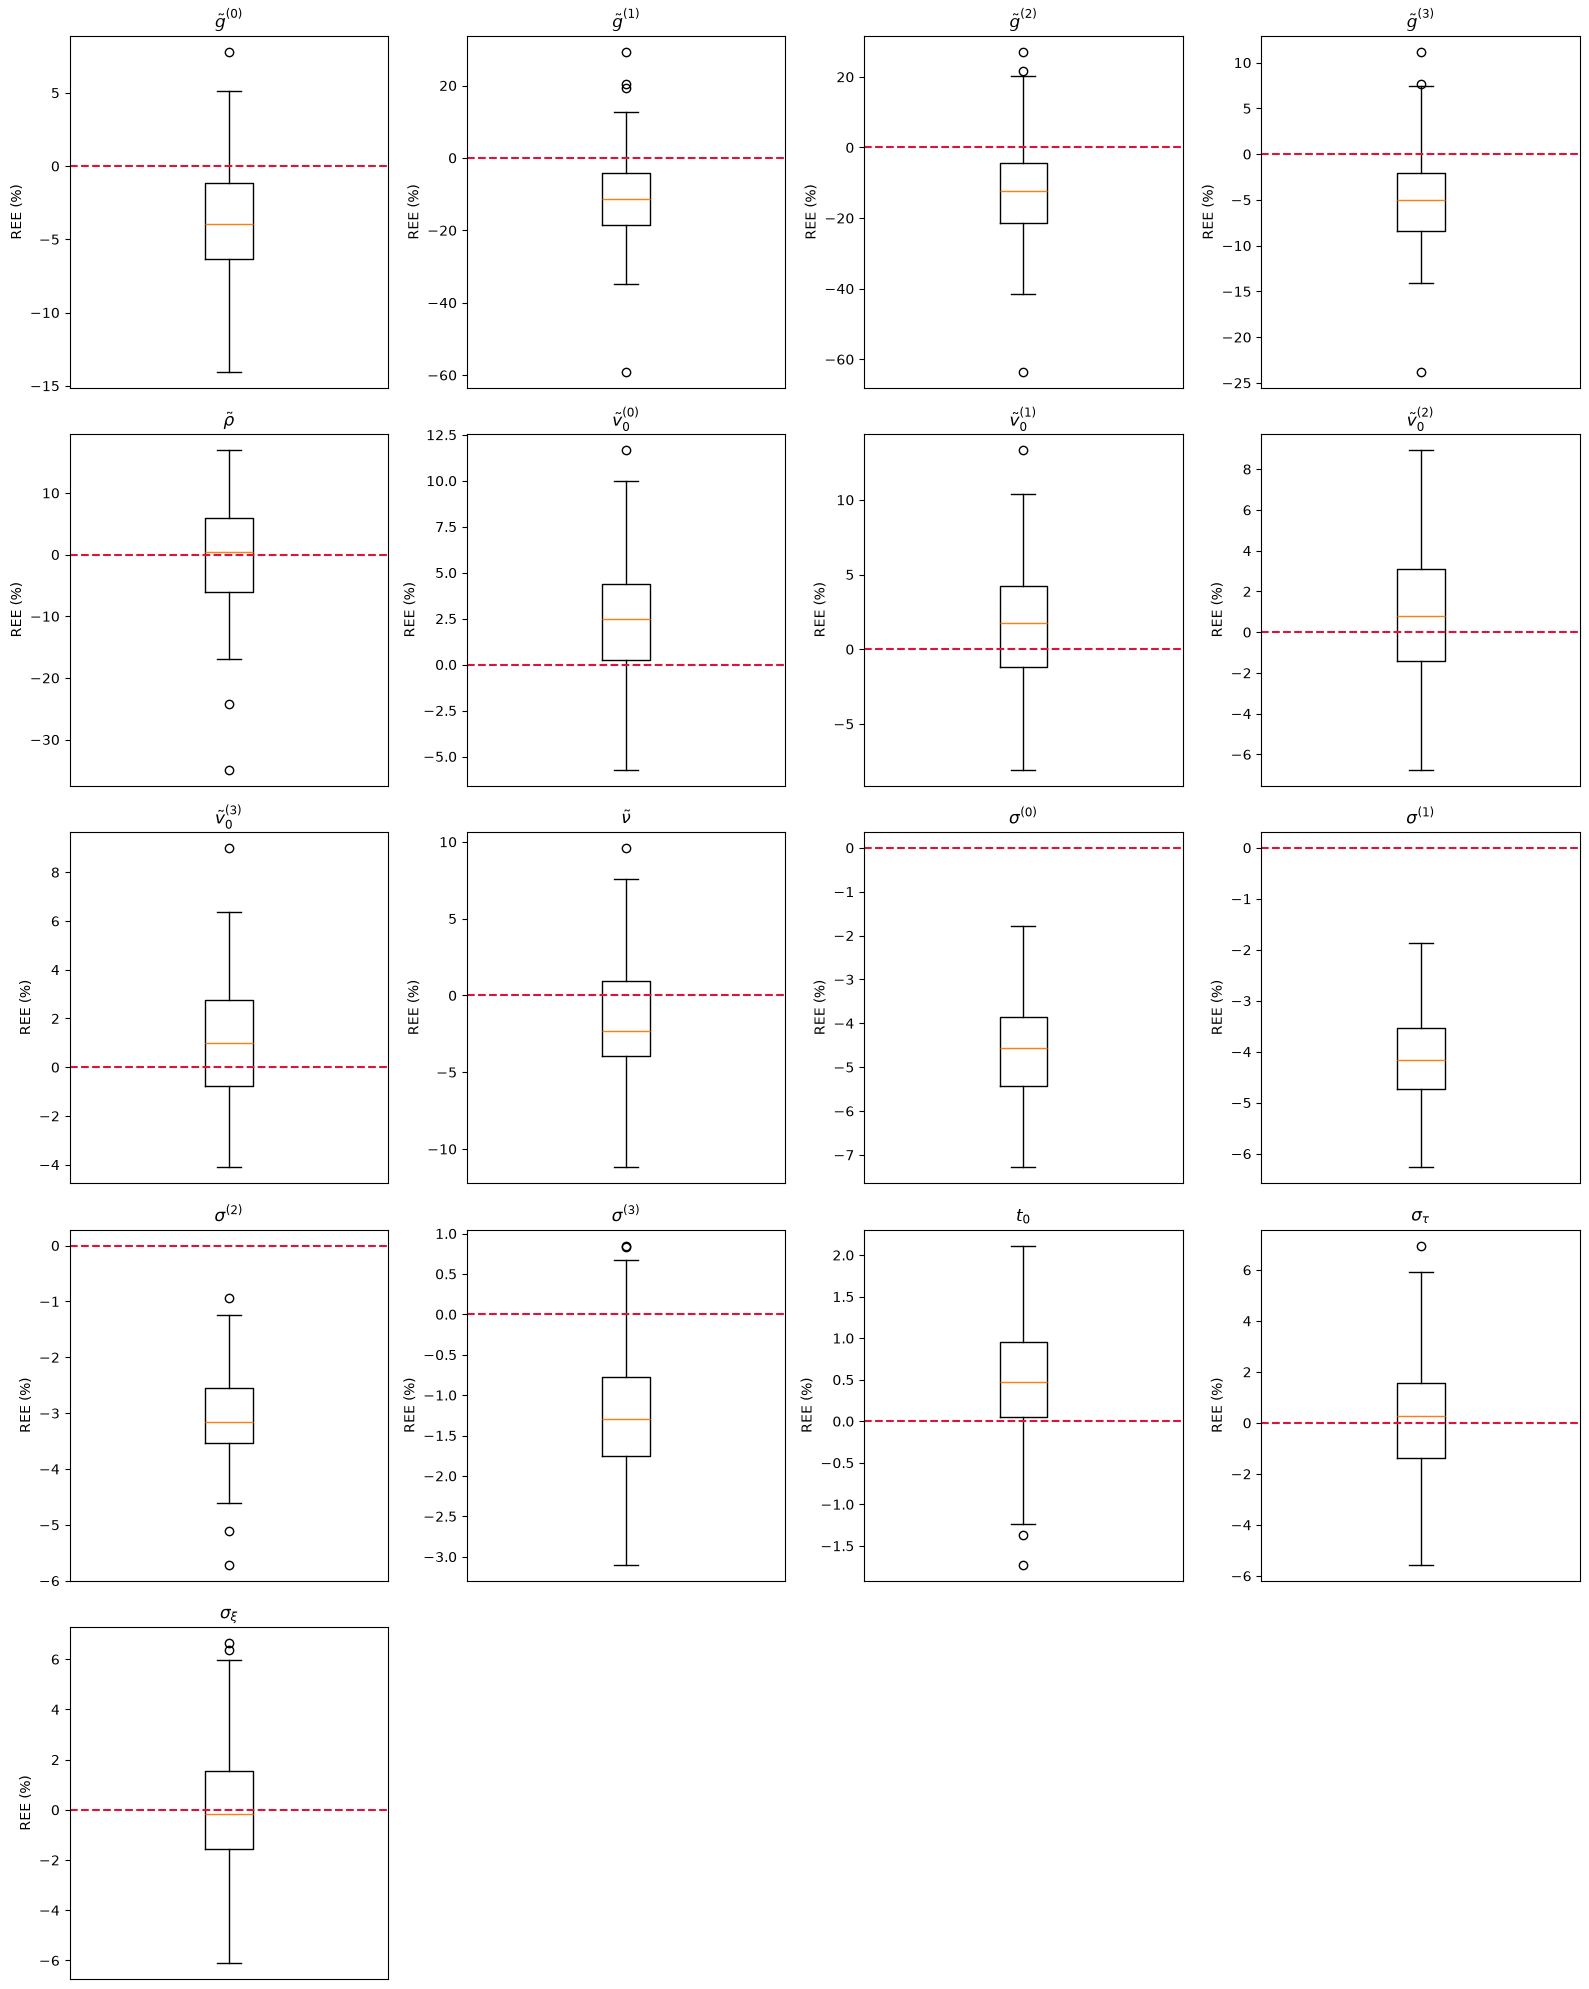

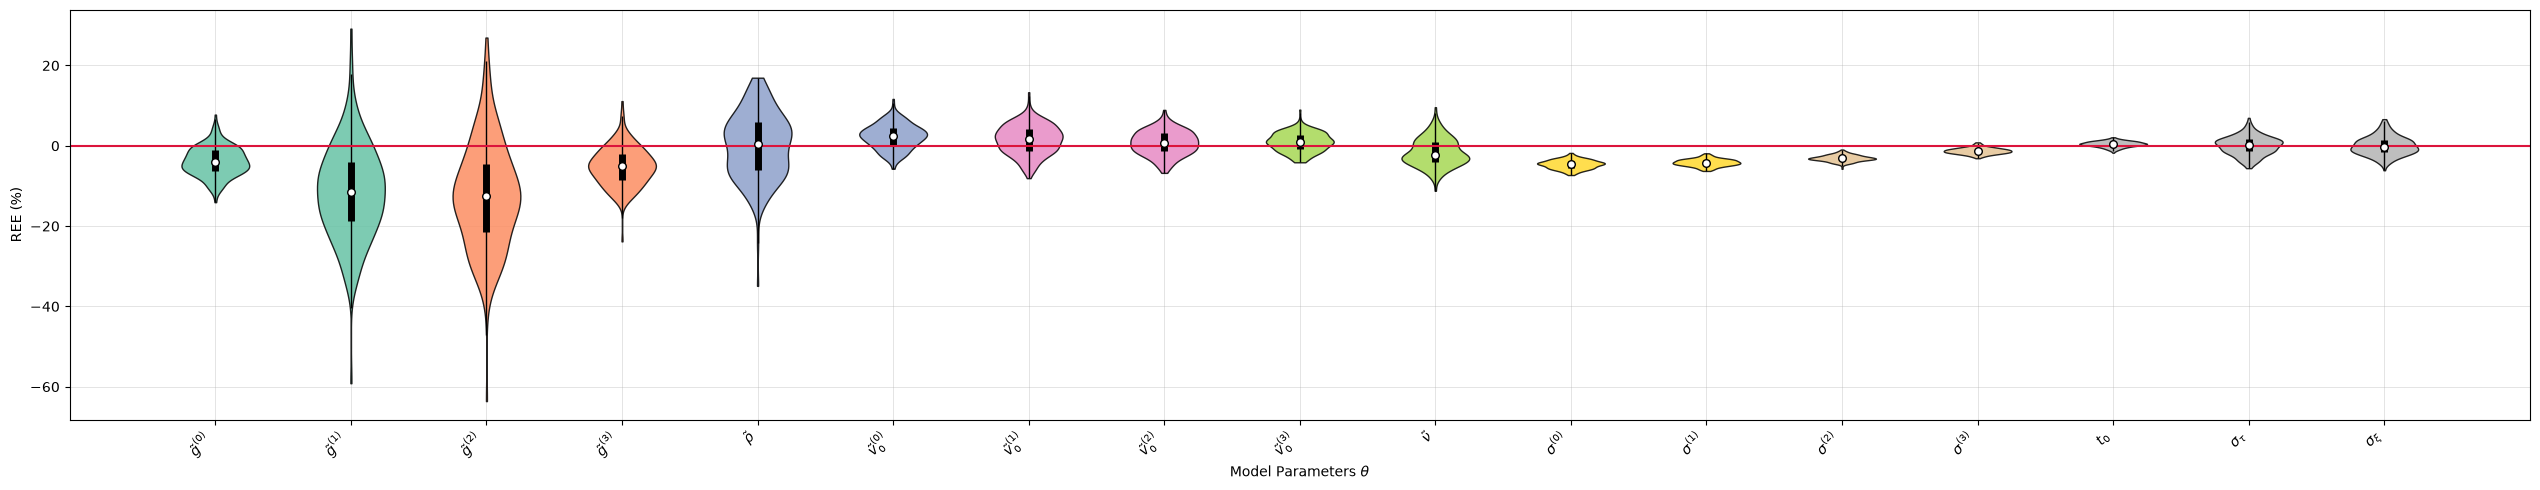

In [14]:
df_metrics, ree_by_label = summarise_population_metrics(theta_true, results)
display(df_metrics)
plot_ree_distributions(ree_by_label)


## Individual Parameters: ICC

Compare true, reference and estimated individual parameters on the current saved results.


In [15]:
def icc_3_1(y_true, y_hat):
    y_true = np.asarray(y_true, dtype=float)
    y_hat = np.asarray(y_hat, dtype=float)
    if len(y_true) < 3:
        return float("nan")
    y = np.stack([y_true, y_hat], axis=1)
    grand_mean = y.mean()
    row_means = y.mean(axis=1)
    ss_between = 2 * np.sum((row_means - grand_mean) ** 2)
    ss_error = np.sum((y - row_means[:, None]) ** 2)
    ms_between = ss_between / (len(y_true) - 1)
    ms_error = ss_error / len(y_true)
    return float((ms_between - ms_error) / (ms_between + ms_error))


def as_matrix(param_dict, key, n_sources):
    values = np.asarray(param_dict[key], dtype=float)
    if values.ndim == 1:
        values = values.reshape(-1, 1)
    return values if values.shape[0] == n_sources else values.T


def mixing_matrix_from_params(param_dict, n_sources, ref_model, obs_model_name, nb_events):
    if n_sources == 0:
        return None
    if "mixing_matrix" in param_dict:
        return as_matrix(param_dict, "mixing_matrix", n_sources)
    model = JointModel(
        name="tmp_projection",
        nb_events=nb_events,
        dimension=ref_model.dimension,
        source_dimension=ref_model.source_dimension,
        obs_models=obs_model_name,
    )
    model.load_parameters(param_dict)
    return model.state["mixing_matrix"].detach().cpu().numpy().copy()


def project_sources(ip_df, source_cols, mixing_matrix=None, zeta=None):
    if ip_df is None or not source_cols:
        return ip_df
    sources = ip_df[source_cols].to_numpy(dtype=float)
    derived = {}
    if mixing_matrix is not None:
        projected = sources @ mixing_matrix
        derived.update({f"__w_{index}__": projected[:, index] for index in range(projected.shape[1])})
    if zeta is not None:
        survival = sources @ zeta
        derived.update({f"__sv_{index}__": survival[:, index] for index in range(survival.shape[1])})
    if not derived:
        return ip_df
    return pd.concat([ip_df, pd.DataFrame(derived, index=ip_df.index)], axis=1)


def matched_arrays(x_df, y_df, column):
    if column not in x_df.columns or column not in y_df.columns:
        return None
    common_ids = x_df.index.astype(str).intersection(y_df.index.astype(str))
    if len(common_ids) < 3:
        return None
    x_values = x_df.loc[x_df.index.astype(str).isin(common_ids), column].to_numpy(dtype=float)
    y_values = y_df.loc[y_df.index.astype(str).isin(common_ids), column].to_numpy(dtype=float)
    return x_values, y_values


def build_ip_context(results, theta_true, ref_model, obs_model_name, nb_events):
    sample = next(df for df in results["true_ips"] if df is not None)
    source_cols = sorted(column for column in sample.columns if column.startswith("sources_"))
    n_sources = len(source_cols)

    mixing_true = mixing_matrix_from_params(theta_true, n_sources, ref_model, obs_model_name, nb_events) if n_sources else None
    zeta_true = as_matrix(theta_true, "zeta_mean", n_sources) if n_sources and "zeta_mean" in theta_true else None

    true_augmented = []
    ref_augmented = []
    est_augmented = []
    for true_df, ref_df, est_df, params in zip(results["true_ips"], results["ref_ips"], results["est_ips"], results["pop_params"]):
        mixing_est = mixing_matrix_from_params(params, n_sources, ref_model, obs_model_name, nb_events) if n_sources else None
        zeta_est = as_matrix(params, "zeta_mean", n_sources) if n_sources and "zeta_mean" in params else None
        true_augmented.append(project_sources(true_df, source_cols, mixing_true, zeta_true))
        ref_augmented.append(project_sources(ref_df, source_cols, mixing_true, zeta_true))
        est_augmented.append(project_sources(est_df, source_cols, mixing_est, zeta_est))

    columns = [("xi", r"$\xi_i$", "log-acceleration"), ("tau", r"$\tau_i$", "time-shift")]
    if mixing_true is not None:
        columns.extend((f"__w_{index}__", rf"$w_{{i,{index}}}$", f"space shift [{index}]") for index in range(mixing_true.shape[1]))
    if zeta_true is not None:
        columns.extend((f"__sv_{index}__", rf"$(\zeta^\top\!\mathbf{{s}}_i)_{{{index}}}$", f"survival shift [{index}]") for index in range(zeta_true.shape[1]))

    return {
        "columns": columns,
        "comparisons": [
            ("true_ips", "est_ips", [(x, y) for x, y in zip(true_augmented, est_augmented) if x is not None and y is not None], "darkorange"),
            ("ref_ips", "est_ips", [(x, y) for x, y in zip(ref_augmented, est_augmented) if x is not None and y is not None], "forestgreen"),
            ("true_ips", "ref_ips", [(x, y) for x, y in zip(true_augmented, ref_augmented) if x is not None and y is not None], "steelblue"),
        ],
        "label_map": {"true_ips": "True", "ref_ips": "Reference", "est_ips": "Estimated"},
    }


def plot_icc_results(ip_context):
    comparisons = ip_context["comparisons"]
    if not any(pairs for _, _, pairs, _ in comparisons):
        print("No valid personalisation results: ICC cannot be computed.")
        return

    print(f"{'x var':10s}  {'y var':10s}  {'IP':25s}  {'ICC(3,1)':>14s}  {'Pearson r':>14s}")
    print("-" * 75)

    for x_name, y_name, pairs, color in comparisons:
        if not pairs:
            continue

        n_plots = len(ip_context["columns"])
        ncols = min(4, n_plots)
        nrows = math.ceil(n_plots / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
        axes = axes.ravel()

        for axis, (column, latex_label, description) in zip(axes, ip_context["columns"]):
            per_sim_icc = []
            per_sim_r = []
            all_x = []
            all_y = []

            for x_df, y_df in pairs:
                matched = matched_arrays(x_df, y_df, column)
                if matched is None:
                    continue
                x_values, y_values = matched
                all_x.append(x_values)
                all_y.append(y_values)
                per_sim_icc.append(icc_3_1(x_values, y_values))
                if np.std(x_values) > 0 and np.std(y_values) > 0:
                    per_sim_r.append(pearsonr(x_values, y_values)[0])

            if not all_x:
                axis.set_visible(False)
                continue

            x_values = np.concatenate(all_x)
            y_values = np.concatenate(all_y)
            low = min(x_values.min(), y_values.min())
            high = max(x_values.max(), y_values.max())
            slope, intercept = np.polyfit(x_values, y_values, 1)

            axis.scatter(x_values, y_values, alpha=0.35, s=12, color=color)
            axis.plot([low, high], [low, high], "r--", lw=1.5, label="identity")
            axis.plot([low, high], [slope * low + intercept, slope * high + intercept], color="grey", lw=1.5, label="linear fit")
            axis.set_xlabel(f"{ip_context['label_map'][x_name]} {latex_label}")
            axis.set_ylabel(f"{ip_context['label_map'][y_name]} {latex_label}")
            axis.legend(fontsize=8)

            mean_icc = np.nanmean(per_sim_icc)
            std_icc = np.nanstd(per_sim_icc)
            mean_r = np.nanmean(per_sim_r) if per_sim_r else float("nan")
            std_r = np.nanstd(per_sim_r) if per_sim_r else float("nan")
            print(f"{x_name:10s}  {y_name:10s}  {description:25s}  {mean_icc:.3f} +/- {std_icc:.3f}  {mean_r:.3f} +/- {std_r:.3f}")

        for axis in axes[len(ip_context['columns']):]:
            axis.set_visible(False)
        plt.tight_layout()
        plt.show()


x var       y var       IP                               ICC(3,1)       Pearson r
---------------------------------------------------------------------------
true_ips    est_ips     log-acceleration           0.988 +/- 0.004  0.989 +/- 0.004
true_ips    est_ips     time-shift                 0.995 +/- 0.002  0.995 +/- 0.002
true_ips    est_ips     space shift [0]            0.987 +/- 0.006  0.992 +/- 0.003
true_ips    est_ips     space shift [1]            0.989 +/- 0.003  0.990 +/- 0.003
true_ips    est_ips     space shift [2]            0.990 +/- 0.003  0.991 +/- 0.003
true_ips    est_ips     space shift [3]            0.987 +/- 0.003  0.988 +/- 0.003
true_ips    est_ips     survival shift [0]         0.965 +/- 0.027  0.978 +/- 0.013


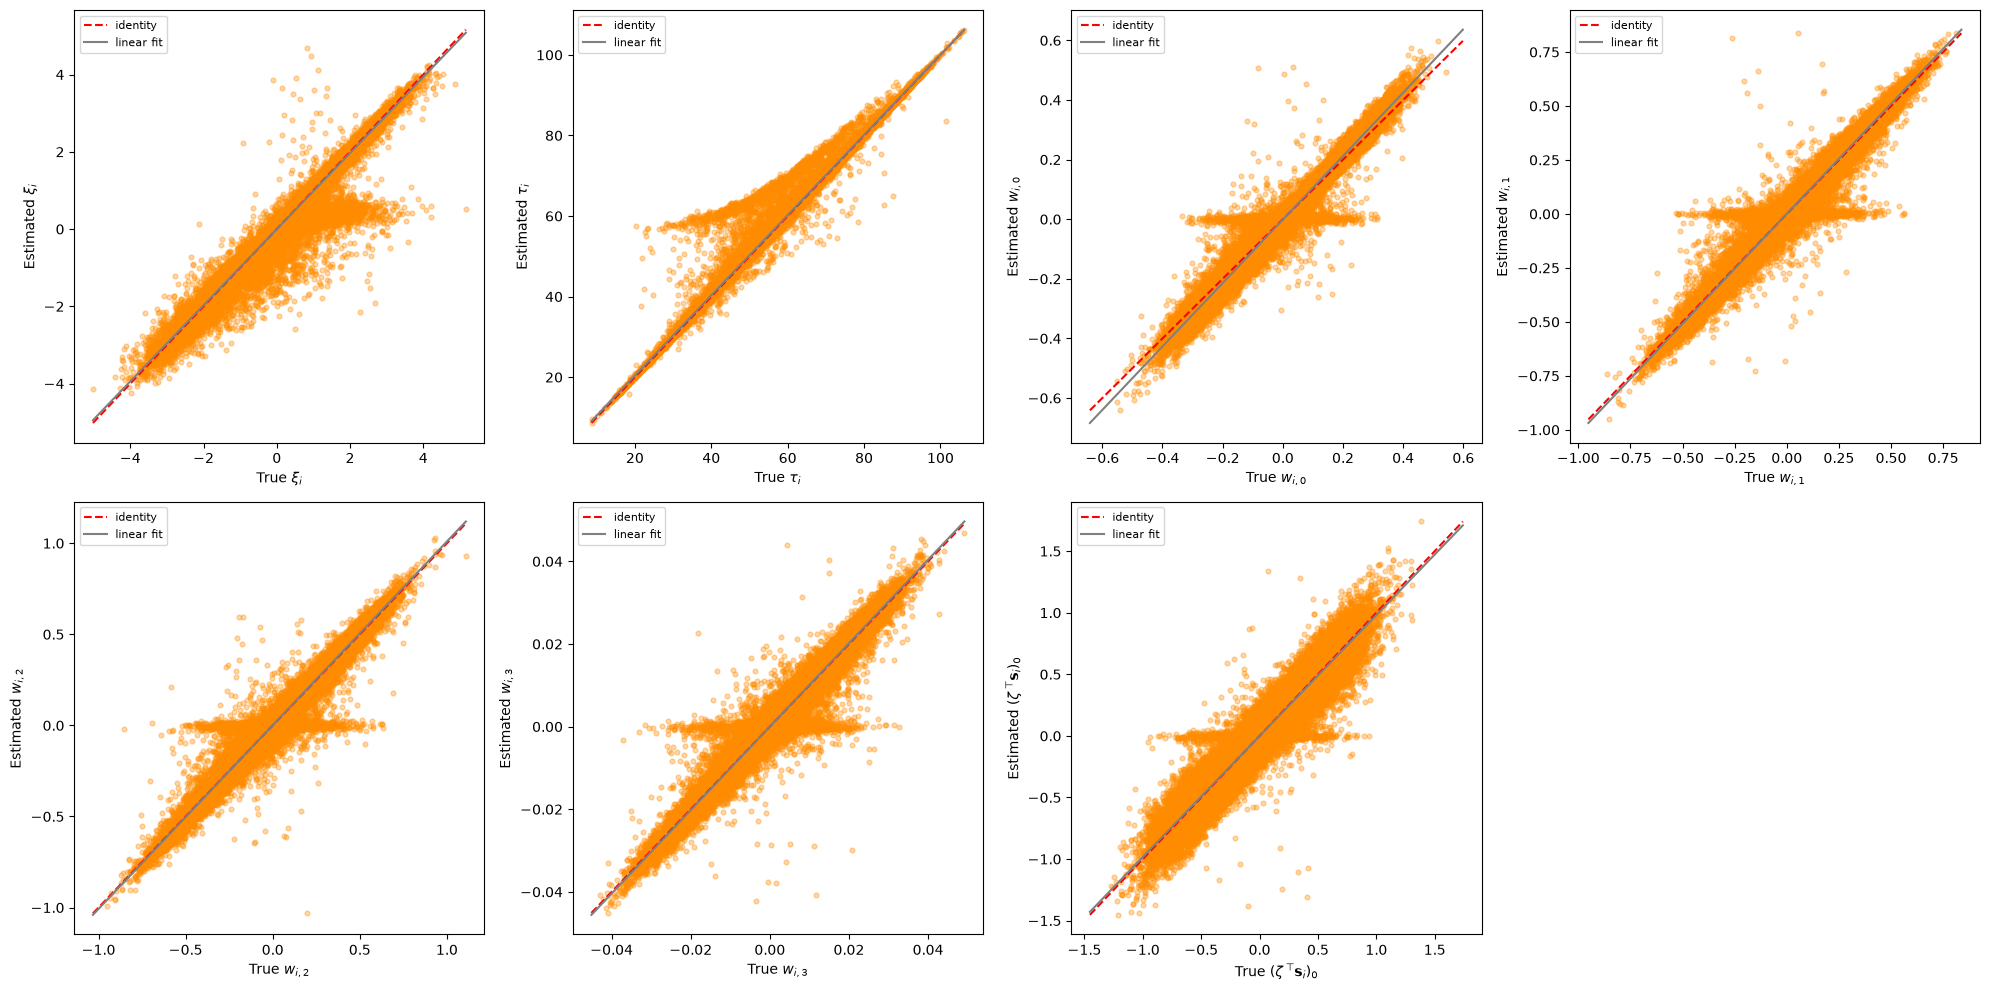

ref_ips     est_ips     log-acceleration           0.998 +/- 0.001  0.999 +/- 0.001
ref_ips     est_ips     time-shift                 0.999 +/- 0.001  0.999 +/- 0.001
ref_ips     est_ips     space shift [0]            0.994 +/- 0.006  1.000 +/- 0.000
ref_ips     est_ips     space shift [1]            0.998 +/- 0.001  1.000 +/- 0.000
ref_ips     est_ips     space shift [2]            0.999 +/- 0.001  1.000 +/- 0.000
ref_ips     est_ips     space shift [3]            0.998 +/- 0.002  0.999 +/- 0.001
ref_ips     est_ips     survival shift [0]         0.975 +/- 0.026  0.989 +/- 0.013


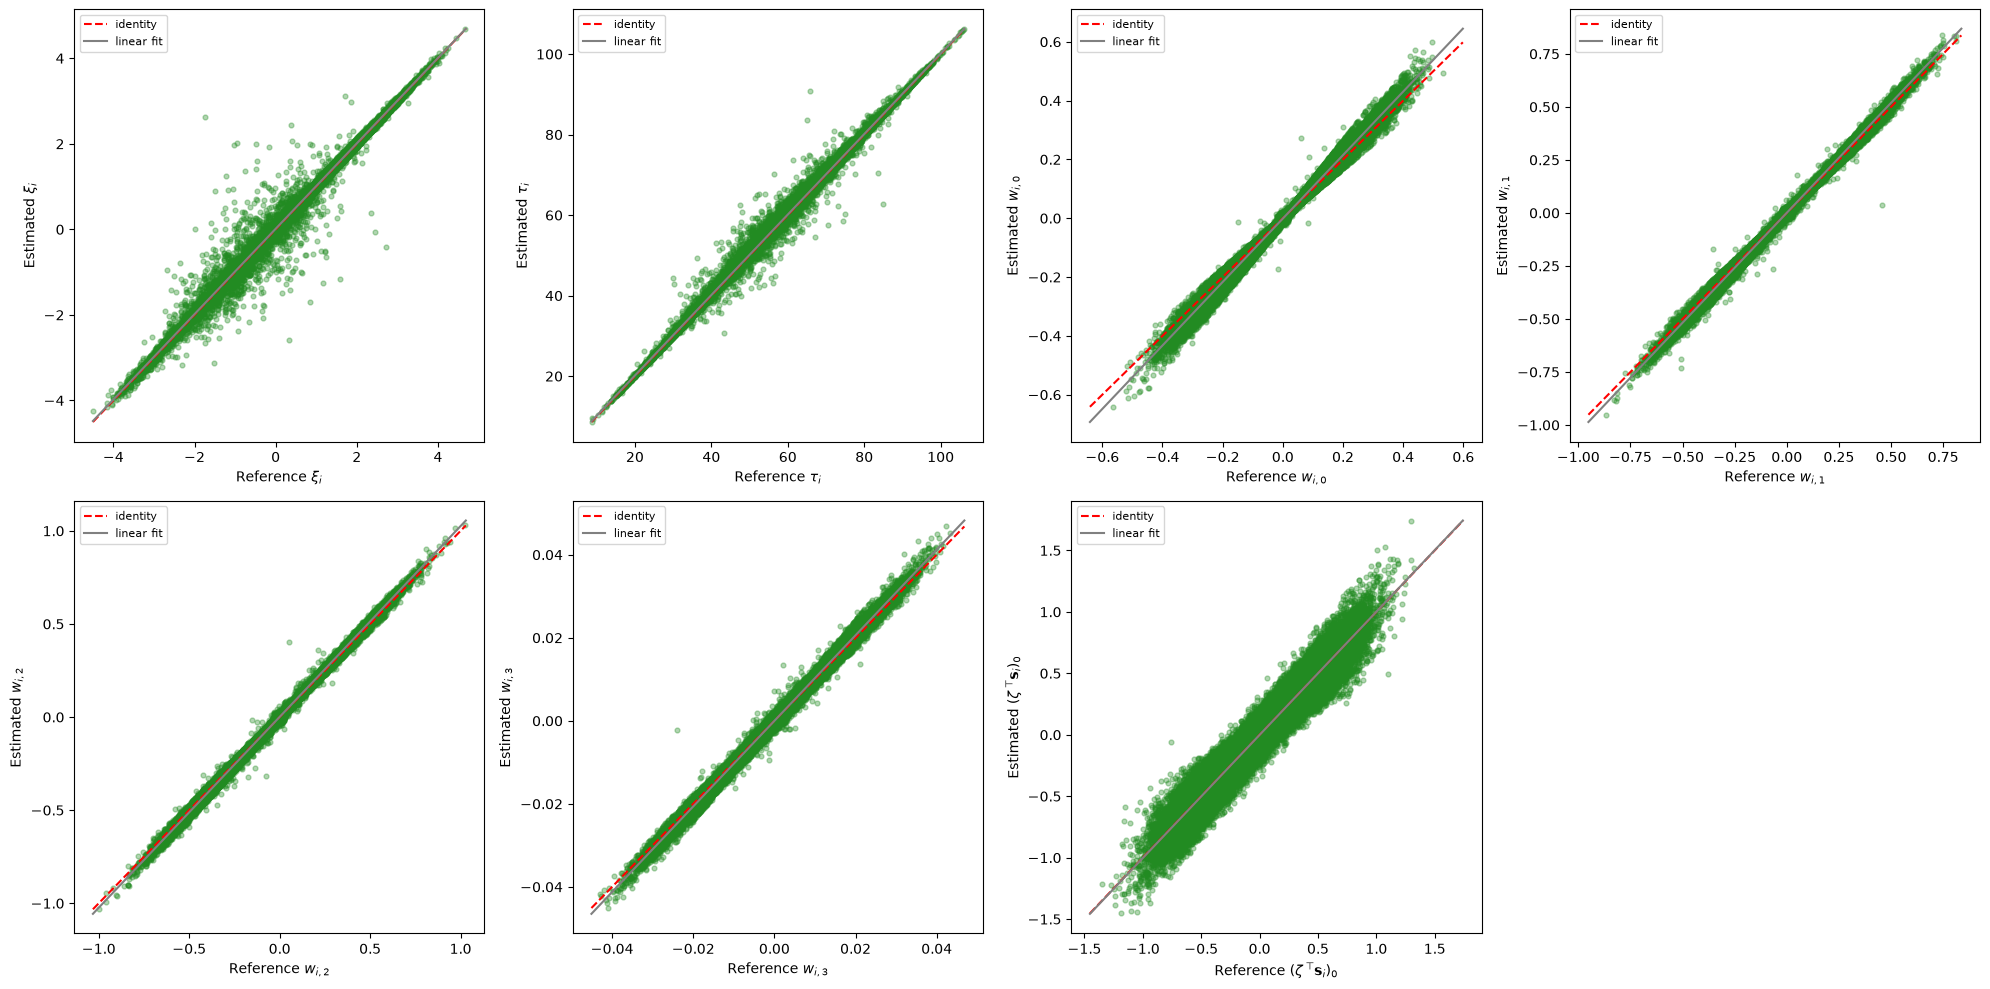

true_ips    ref_ips     log-acceleration           0.989 +/- 0.004  0.989 +/- 0.004
true_ips    ref_ips     time-shift                 0.996 +/- 0.002  0.996 +/- 0.002
true_ips    ref_ips     space shift [0]            0.992 +/- 0.003  0.992 +/- 0.003
true_ips    ref_ips     space shift [1]            0.990 +/- 0.003  0.990 +/- 0.003
true_ips    ref_ips     space shift [2]            0.991 +/- 0.003  0.991 +/- 0.003
true_ips    ref_ips     space shift [3]            0.989 +/- 0.003  0.989 +/- 0.003
true_ips    ref_ips     survival shift [0]         0.989 +/- 0.003  0.989 +/- 0.003


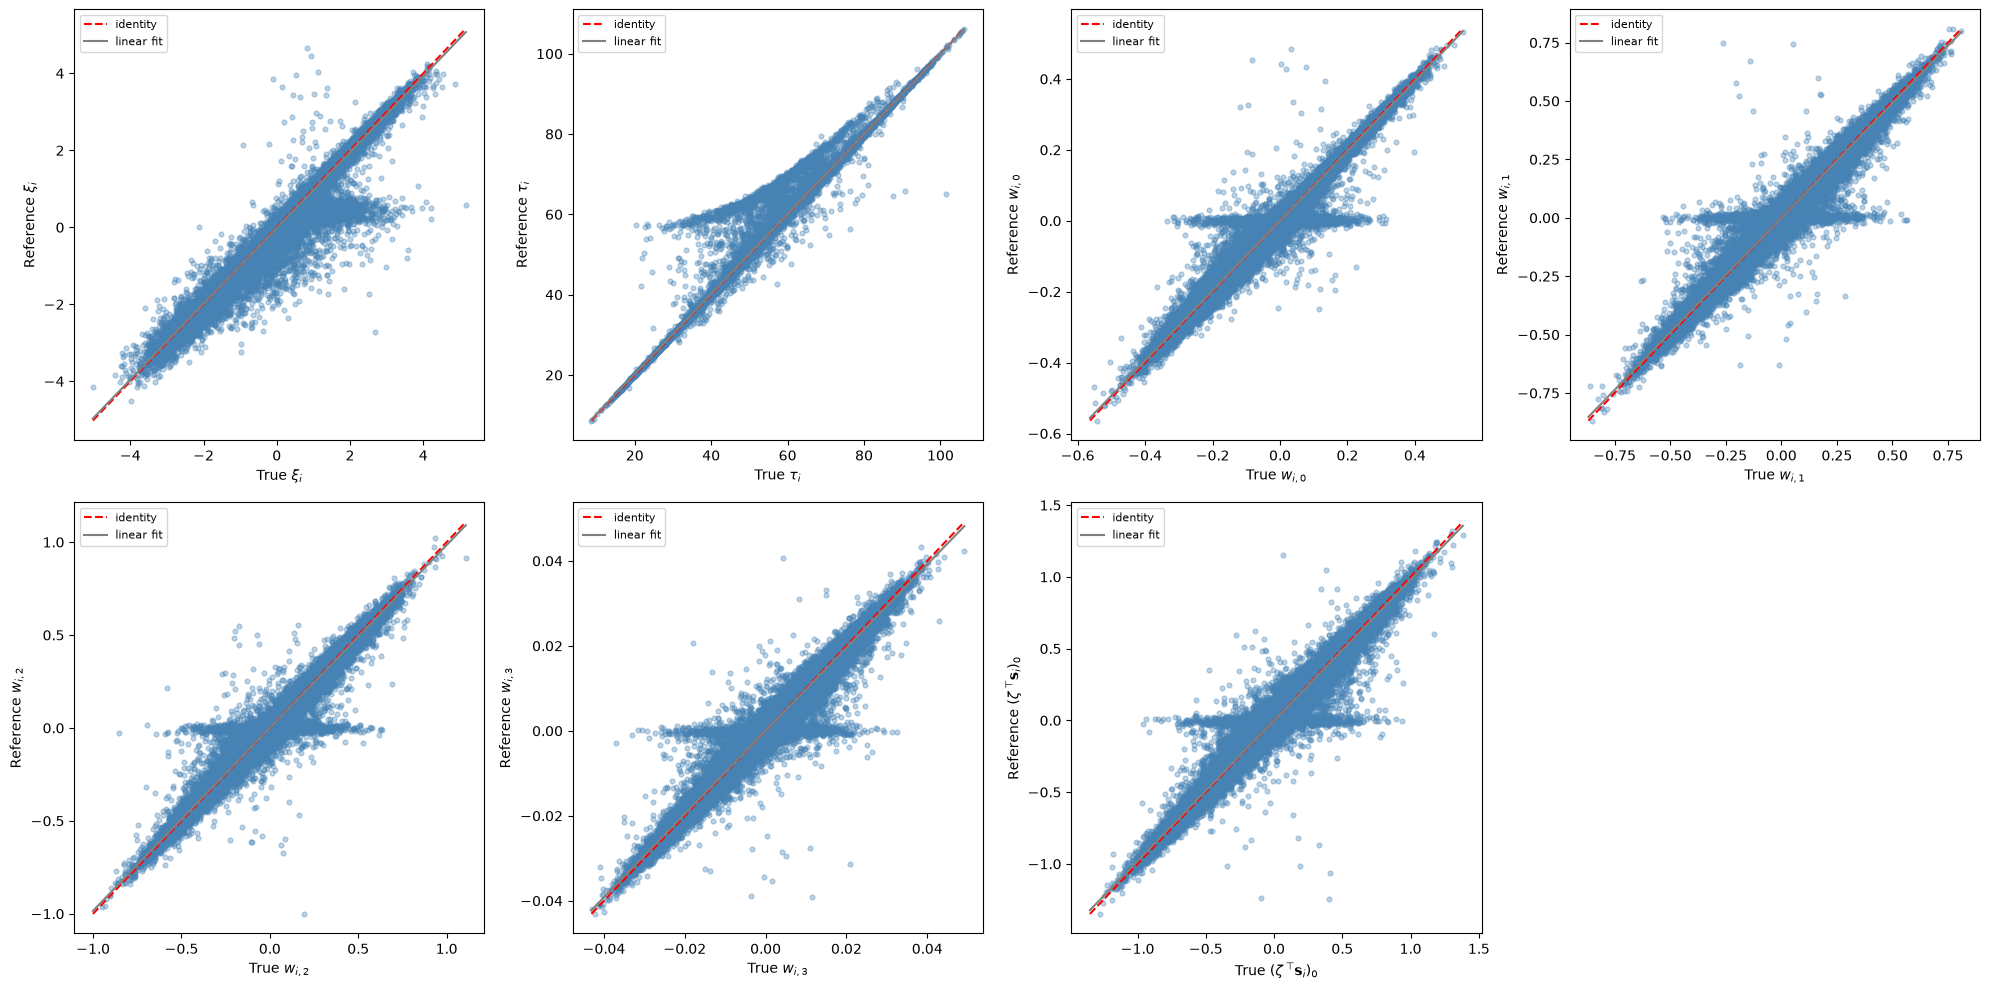

In [16]:
ip_context = build_ip_context(results, theta_true, ref_model, obs_model_name, NB_EVENTS)
plot_icc_results(ip_context)


## Individual Parameters: Bland-Altman

Use the same aligned individual-parameter comparisons to assess bias and limits of agreement.


In [17]:
def matched_arrays(x_df, y_df, column):
    if column not in x_df.columns or column not in y_df.columns:
        return None
    common_ids = x_df.index.astype(str).intersection(y_df.index.astype(str))
    if len(common_ids) < 3:
        return None
    x_values = x_df.loc[x_df.index.astype(str).isin(common_ids), column].to_numpy(dtype=float)
    y_values = y_df.loc[y_df.index.astype(str).isin(common_ids), column].to_numpy(dtype=float)
    return x_values, y_values


def plot_bland_altman_results(ip_context):
    comparisons = ip_context["comparisons"]
    short_label_map = {"true_ips": "True", "ref_ips": "Ref.", "est_ips": "Est."}

    if not any(pairs for _, _, pairs, _ in comparisons):
        print("No valid personalisation results: Bland-Altman cannot be computed.")
        return

    print(f"{'x var':10s}  {'y var':10s}  {'IP':25s}  {'Bias':>10s}  {'LoA lower':>12s}  {'LoA upper':>12s}")
    print("-" * 75)

    for x_name, y_name, pairs, color in comparisons:
        if not pairs:
            continue

        n_plots = len(ip_context["columns"])
        ncols = min(4, n_plots)
        nrows = math.ceil(n_plots / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
        axes = axes.ravel()

        for axis, (column, latex_label, description) in zip(axes, ip_context["columns"]):
            all_means = []
            all_diffs = []

            for x_df, y_df in pairs:
                matched = matched_arrays(x_df, y_df, column)
                if matched is None:
                    continue
                x_values, y_values = matched
                all_means.append((x_values + y_values) / 2)
                all_diffs.append(y_values - x_values)

            if not all_means:
                axis.set_visible(False)
                continue

            means = np.concatenate(all_means)
            diffs = np.concatenate(all_diffs)
            bias = float(diffs.mean())
            std = float(diffs.std(ddof=1))
            loa_low = bias - 1.96 * std
            loa_high = bias + 1.96 * std

            x_label = short_label_map[x_name]
            y_label = short_label_map[y_name]
            axis.scatter(means, diffs, alpha=0.35, s=12, color=color)
            axis.axhline(bias, color="black", lw=1.5, linestyle="-", label=f"Bias = {bias:.3f}")
            axis.axhline(loa_high, color="crimson", lw=1.2, linestyle="--", label=f"+1.96 SD = {loa_high:.3f}")
            axis.axhline(loa_low, color="crimson", lw=1.2, linestyle="--", label=f"-1.96 SD = {loa_low:.3f}")
            axis.axhline(0, color="grey", lw=0.8, linestyle=":")
            axis.set_xlabel(f"Mean({x_label}, {y_label}) {latex_label}")
            axis.set_ylabel(f"Δ{latex_label} ({y_label} - {x_label})")
            axis.legend(fontsize=8)
            print(f"{x_name:10s}  {y_name:10s}  {description:25s}  {bias:+10.4f}  {loa_low:+12.4f}  {loa_high:+12.4f}")

        for axis in axes[len(ip_context['columns']):]:
            axis.set_visible(False)
        plt.tight_layout()
        plt.show()


x var       y var       IP                               Bias     LoA lower     LoA upper
---------------------------------------------------------------------------
true_ips    est_ips     log-acceleration              -0.0025       -0.3242       +0.3192
true_ips    est_ips     time-shift                    +0.2385       -1.9937       +2.4707
true_ips    est_ips     space shift [0]               -0.0010       -0.0417       +0.0396
true_ips    est_ips     space shift [1]               +0.0009       -0.0564       +0.0581
true_ips    est_ips     space shift [2]               +0.0011       -0.0599       +0.0621
true_ips    est_ips     space shift [3]               -0.0000       -0.0033       +0.0033
true_ips    est_ips     survival shift [0]            -0.0010       -0.1603       +0.1583


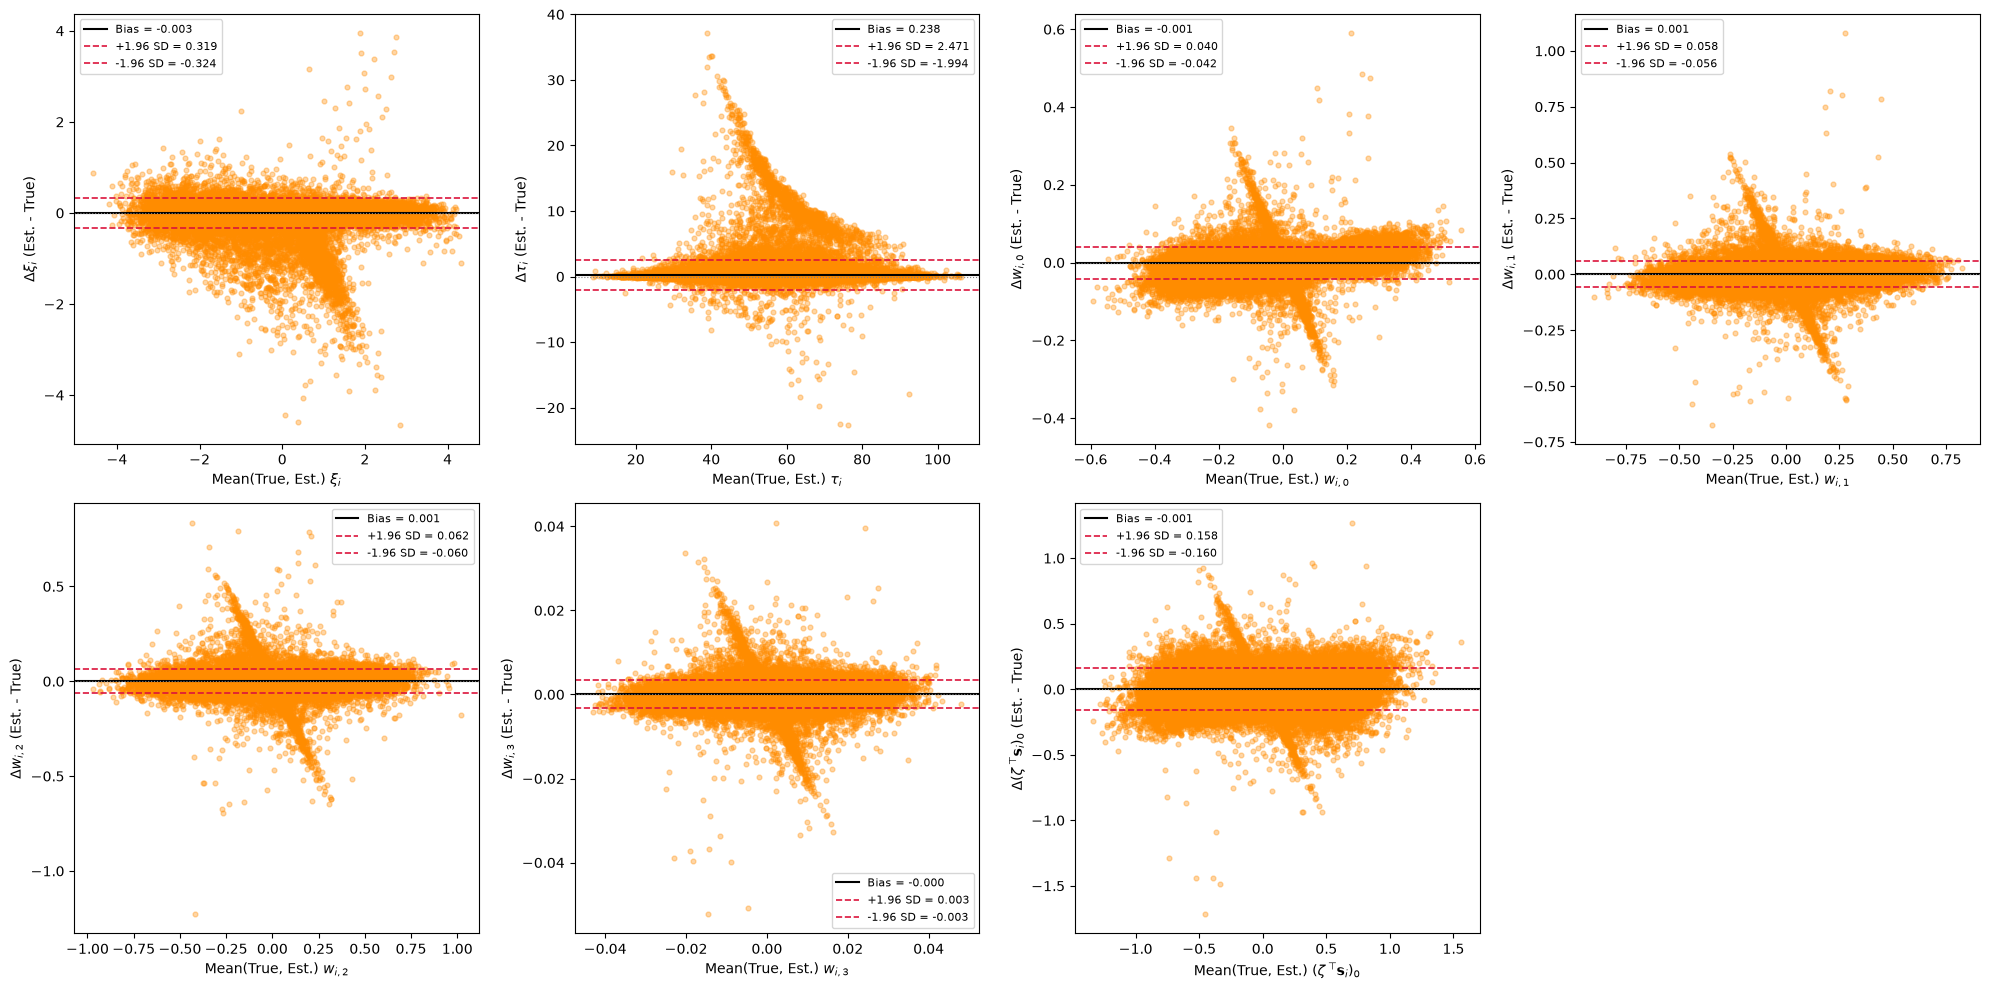

ref_ips     est_ips     log-acceleration              +0.0143       -0.1141       +0.1426
ref_ips     est_ips     time-shift                    +0.1504       -0.7049       +1.0057
ref_ips     est_ips     space shift [0]               -0.0010       -0.0286       +0.0267
ref_ips     est_ips     space shift [1]               +0.0008       -0.0221       +0.0236
ref_ips     est_ips     space shift [2]               +0.0010       -0.0197       +0.0217
ref_ips     est_ips     space shift [3]               -0.0000       -0.0014       +0.0014
ref_ips     est_ips     survival shift [0]            -0.0009       -0.1338       +0.1321


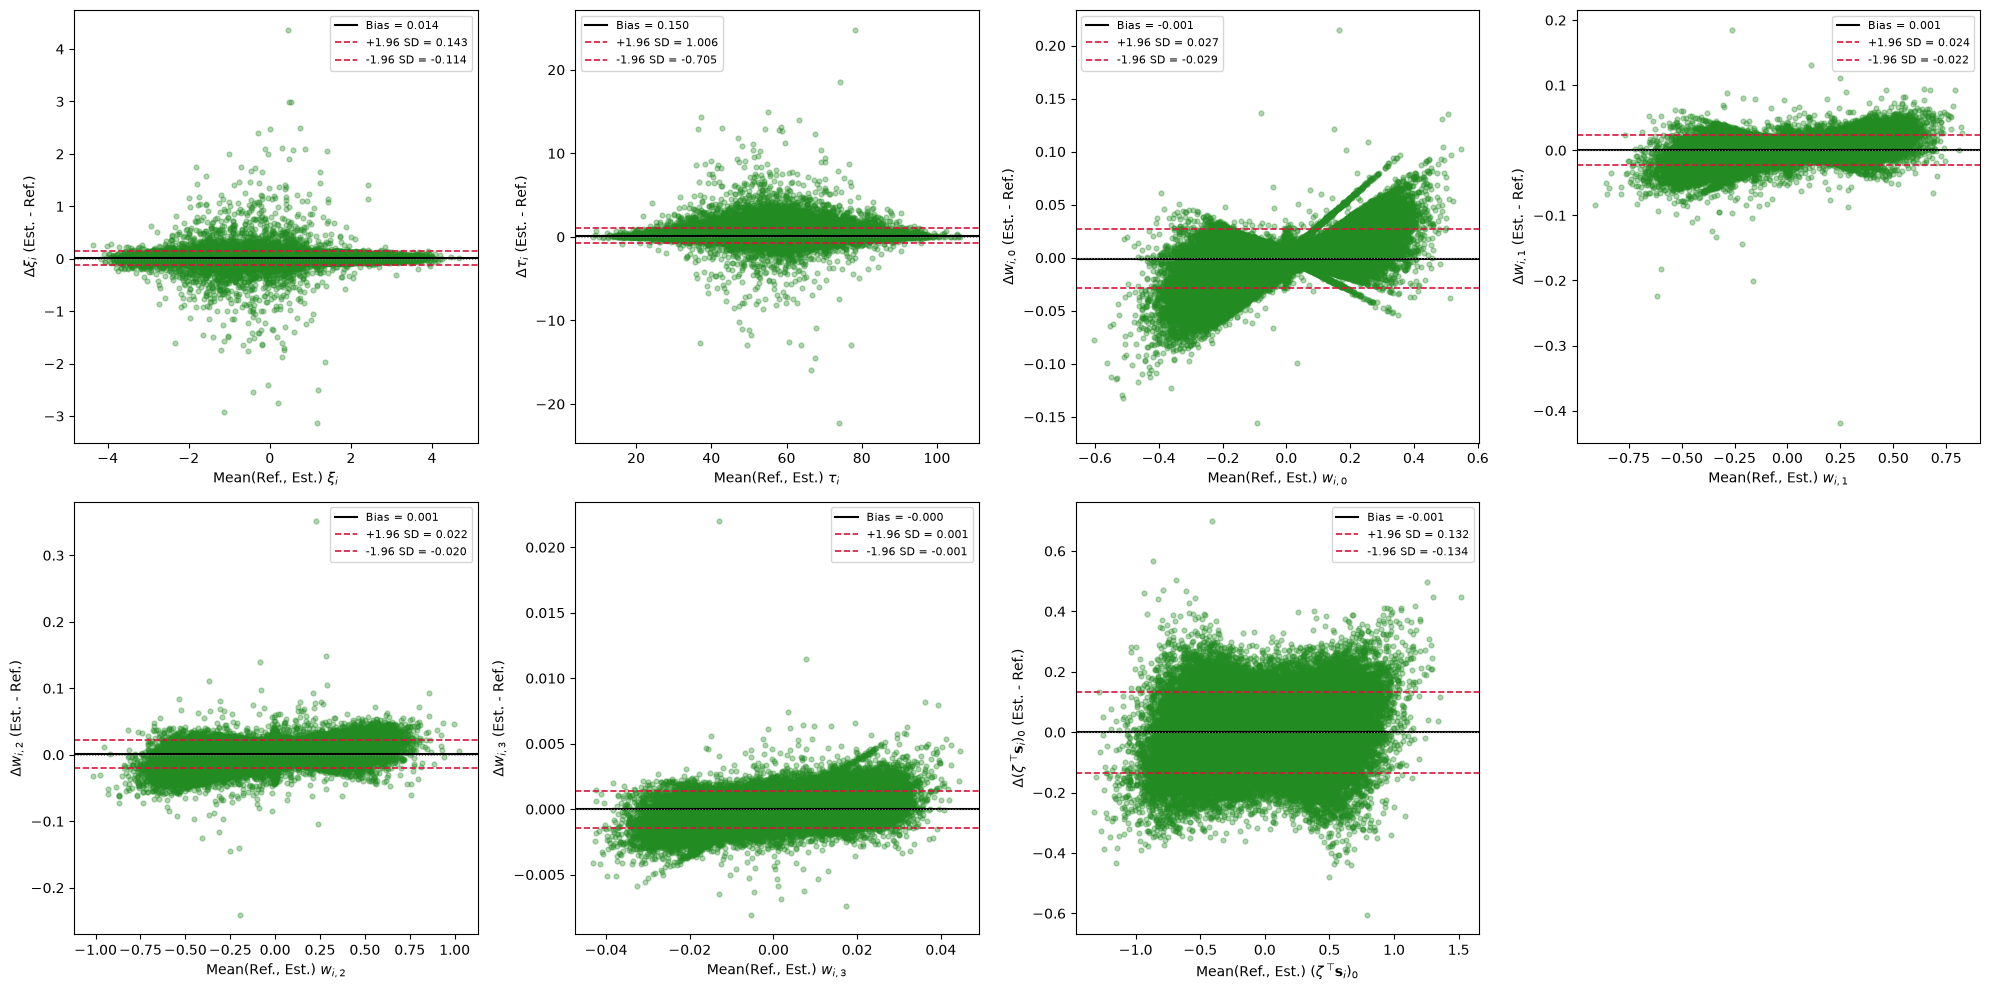

true_ips    ref_ips     log-acceleration              -0.0168       -0.3312       +0.2977
true_ips    ref_ips     time-shift                    +0.0881       -2.0398       +2.2160
true_ips    ref_ips     space shift [0]               -0.0001       -0.0300       +0.0299
true_ips    ref_ips     space shift [1]               +0.0001       -0.0527       +0.0529
true_ips    ref_ips     space shift [2]               +0.0001       -0.0575       +0.0577
true_ips    ref_ips     space shift [3]               -0.0000       -0.0030       +0.0030
true_ips    ref_ips     survival shift [0]            -0.0001       -0.0881       +0.0879


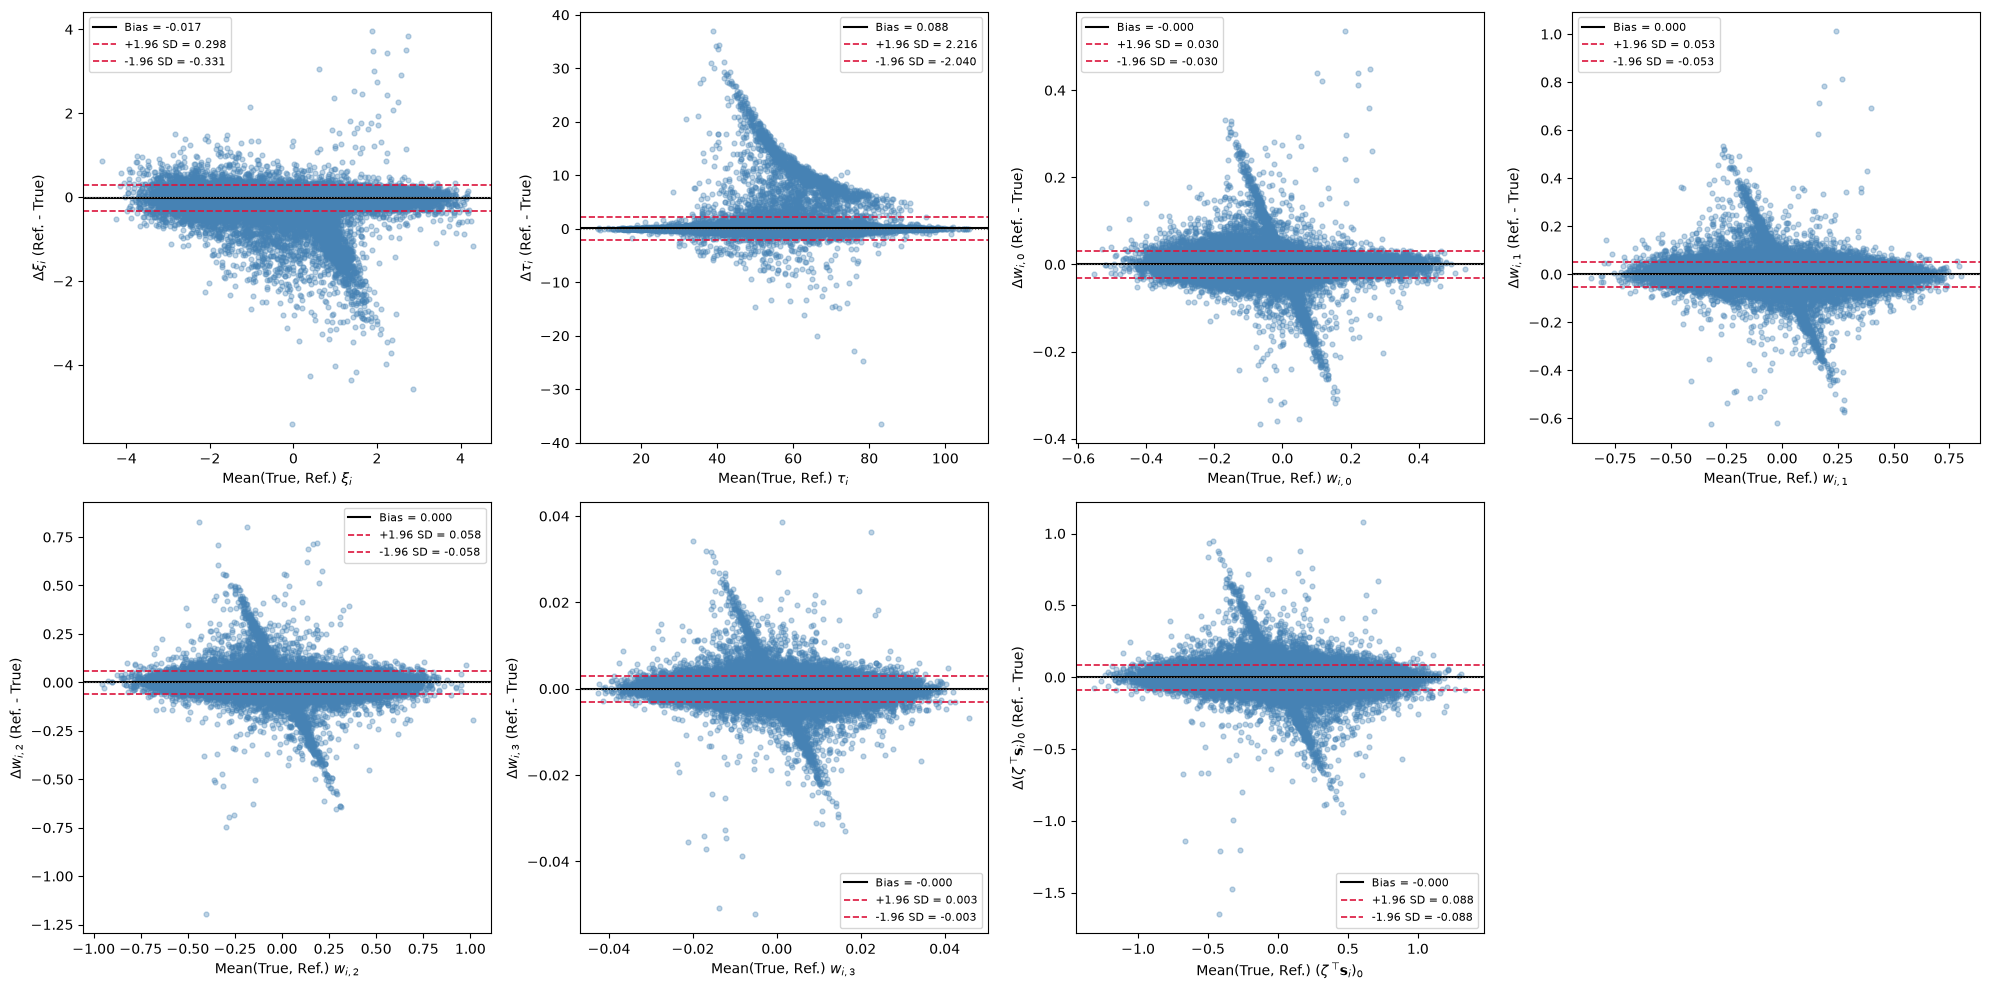

In [18]:
plot_bland_altman_results(ip_context)


## Example Simulated Trajectories

Draw one simulated dataset from the reference model and inspect a few patient trajectories.


In [19]:
def show_example_trajectories(ref_model, features, visit_params, n_show=5, n_features=4, seed=12):
    from leaspy.io.logs.visualization.plotting import Plotting

    np.random.seed(seed)
    torch.manual_seed(seed)
    result = ref_model.simulate(
        algorithm="joint_simulate",
        features=features,
        visit_parameters=visit_params,
    )
    df_example = result.data.to_dataframe()
    ip_example = result.individual_parameters.copy()
    ip_example.index.name = "ID"

    event_time_col = result.data.event_time_name
    event_bool_col = result.data.event_bool_name
    shown_ids = df_example["ID"].unique()[:n_show]

    display(df_example[df_example["ID"].isin(shown_ids)][["ID", "TIME", event_time_col, event_bool_col] + features[:n_features]])

    plotter = Plotting(ref_model)
    for patient_id in shown_ids:
        axis = plotter.patient_trajectories(
            data=result.data,
            individual_parameters=ip_example,
            patients_idx=[patient_id],
            features=features[:n_features],
        )
        axis.set_title(f"Patient {patient_id}")
        plt.show()



Simulate with `joint_simulate` took: 8.78s


,ID,TIME,EVENT_TIME,EVENT_BOOL,ALSFRS_R_BULBAR,ALSFRS_R_FINE_MOTOR,ALSFRS_R_GROSS_MOTOR,ALSFRS_R_TOTAL
0,0,77.65,81.663778,0,3.997723e-06,0.235231,0.002858,0.056605
1,0,77.74,81.663778,0,8.789139e-06,0.094361,0.000800,0.060652
2,0,77.83,81.663778,0,4.840653e-03,0.038847,0.020754,0.075799
3,0,77.89,81.663778,0,1.184803e-03,0.189067,0.058602,0.082173
4,0,77.97,81.663778,0,3.058276e-10,0.148016,0.047320,0.091267
...,...,...,...,...,...,...,...,...
236,3,63.40,63.509895,0,2.363927e-01,0.597210,0.337640,0.319609
237,4,68.80,69.034165,1,8.337479e-01,0.032085,0.716331,0.400947
238,4,68.88,69.034165,1,8.718472e-01,0.185655,0.516040,0.459961
239,4,68.93,69.034165,1,8.582459e-01,0.073841,0.679920,0.466476


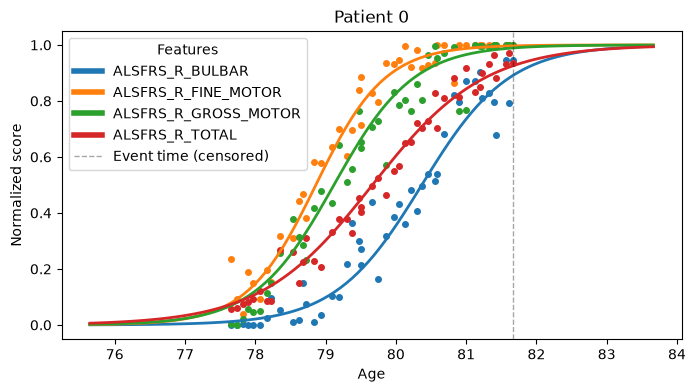

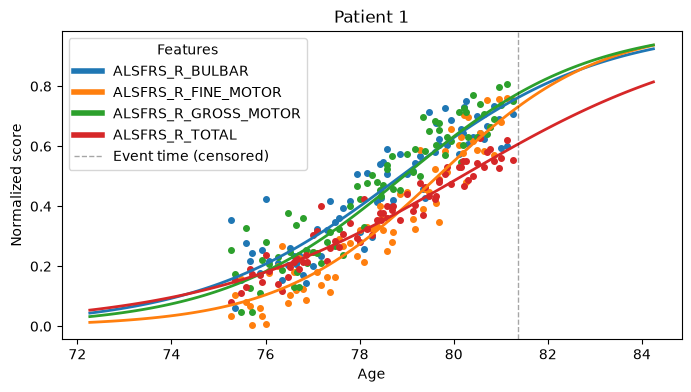

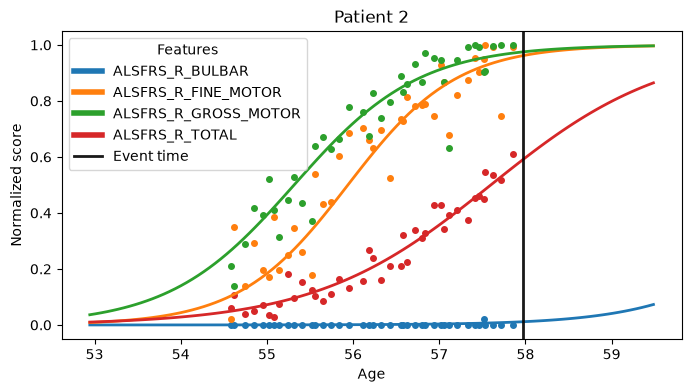

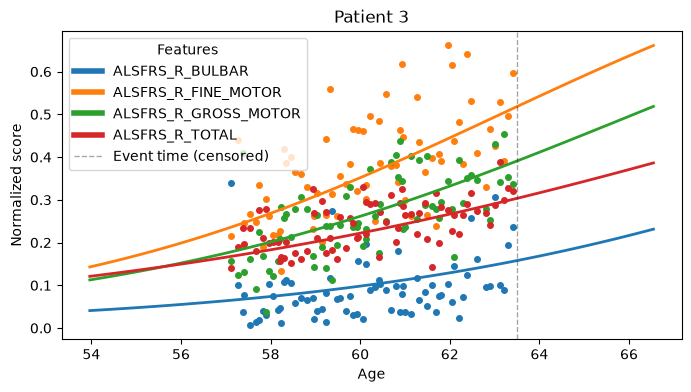

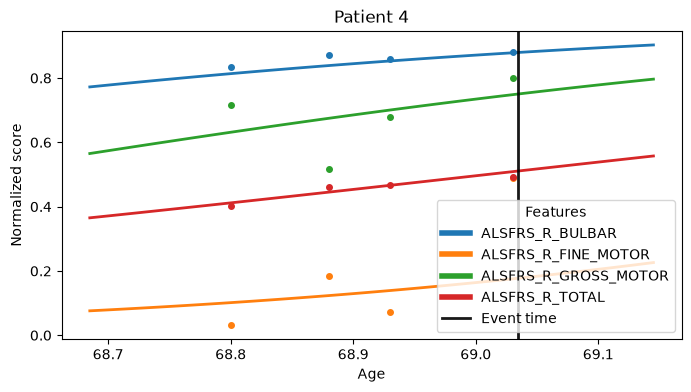

In [20]:
show_example_trajectories(ref_model, features, visit_params)
